# Fashion MNIST

This dataset is native to the TensorFlow library. This dataset contains images across various clothing / footwear / accessories categories.

The proposed solution utilizes a CNN architecture of Conv2D layers, flattening operarions and dense layers.

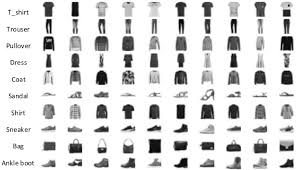


In [1]:
#CNN code (1/N)

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout
from tensorflow.keras.models import Model

fashion_mnist = tf.keras.datasets.fashion_mnist

(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
#print(x_train.shape)

x_train = np.expand_dims(x_train, -1) #The train dataset is 2D. Convolution expects 3D dimension: height X width X color.
x_test = np.expand_dims(x_test, -1)
#print(x_train.shape)

K = len(set(y_train))
#print(K)

#Build the CNN
i = Input(shape = x_train[0].shape)
x = Conv2D(32, (3,3), strides = 2, activation = 'relu')(i)
x = Conv2D(64, (3,3), strides = 2, activation = 'relu')(x)
x = Conv2D(128, (3,3), strides = 2, activation = 'relu')(x)
x = Flatten()(x)
x = Dropout(0.2)(x)
x = Dense(512, activation = 'relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation = 'softmax')(x)

model = Model(i, x)

#Compule and fit
model.compile(optimizer = 'adam',
              loss = 'sparse_categorical_crossentropy',
              metrics = ['accuracy'])

r = model.fit(x_train, y_train, validation_data = (x_test, y_test), epochs = 15)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 4ms/step - accuracy: 0.8086 - loss: 0.5187 - val_accuracy: 0.8525 - val_loss: 0.3989
Epoch 2/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8644 - loss: 0.3628 - val_accuracy: 0.8712 - val_loss: 0.3453
Epoch 3/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8837 - loss: 0.3104 - val_accuracy: 0.8812 - val_loss: 0.3269
Epoch 4/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8957 - loss: 0.2769 - val_accuracy: 0.8821 - val_loss: 0.3156
Epoch 5/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9048 - loss: 0.2536 - val_accuracy: 0.8811 - val_loss: 0.3192
Epoch 6/15
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.9125 - loss: 0.2314 - val_accuracy: 0.8909 - val_loss: 0.3075
Epoch 7/15
1875/1875 ━━━━━━━━━━

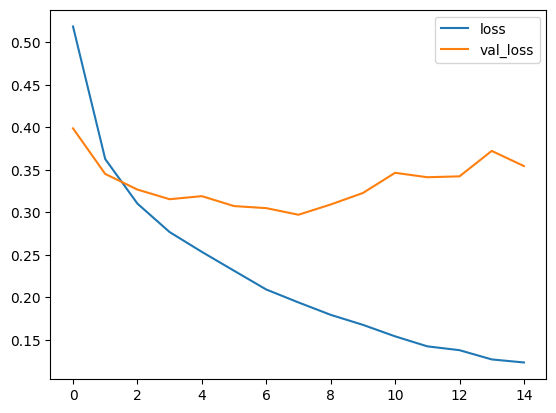

In [2]:
from IPython.core import history
#CNN code (2/N)

import matplotlib
plt.plot(r.history['loss'], label = 'loss')
plt.plot(r.history['val_loss'], label = 'val_loss')
plt.legend()

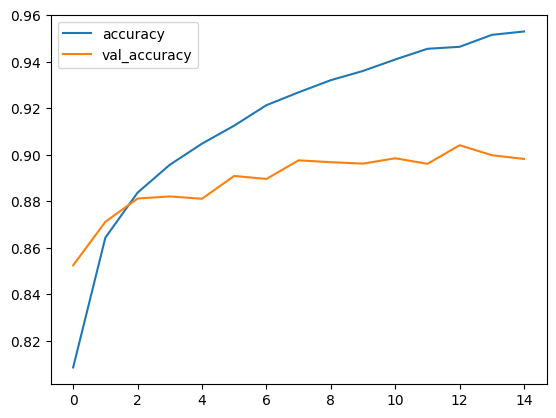

In [3]:
from IPython.core import history
#CNN code (3/N)

import matplotlib
plt.plot(r.history['accuracy'], label = 'accuracy')
plt.plot(r.history['val_accuracy'], label = 'val_accuracy')
plt.legend()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


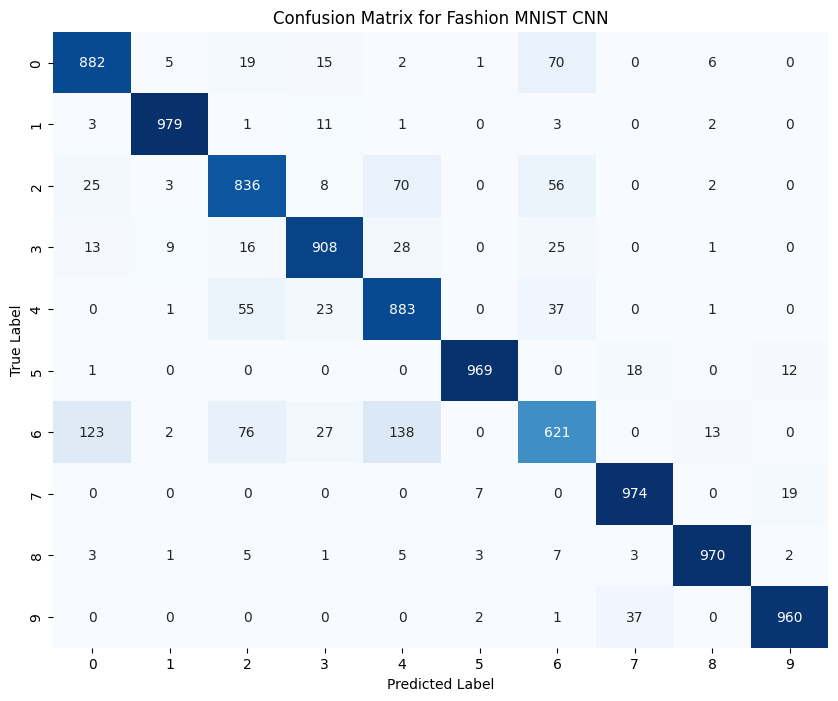

In [4]:
#CNN code (4/N)

import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Get predictions for the test set
y_pred_probabilities = model.predict(x_test)
y_pred_classes = np.argmax(y_pred_probabilities, axis=1)

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Fashion MNIST CNN')
plt.show()

Top misclassified archetypes:
  Actual 'Shirt' predicted as 'Coat' (138 times)
  Actual 'Shirt' predicted as 'T-shirt/top' (123 times)
  Actual 'Shirt' predicted as 'Pullover' (76 times)
  Actual 'T-shirt/top' predicted as 'Shirt' (70 times)
  Actual 'Pullover' predicted as 'Coat' (70 times)
  Actual 'Pullover' predicted as 'Shirt' (56 times)
  Actual 'Coat' predicted as 'Pullover' (55 times)
  Actual 'Coat' predicted as 'Shirt' (37 times)
  Actual 'Ankle boot' predicted as 'Sneaker' (37 times)

Displaying 9 unique misclassified examples.


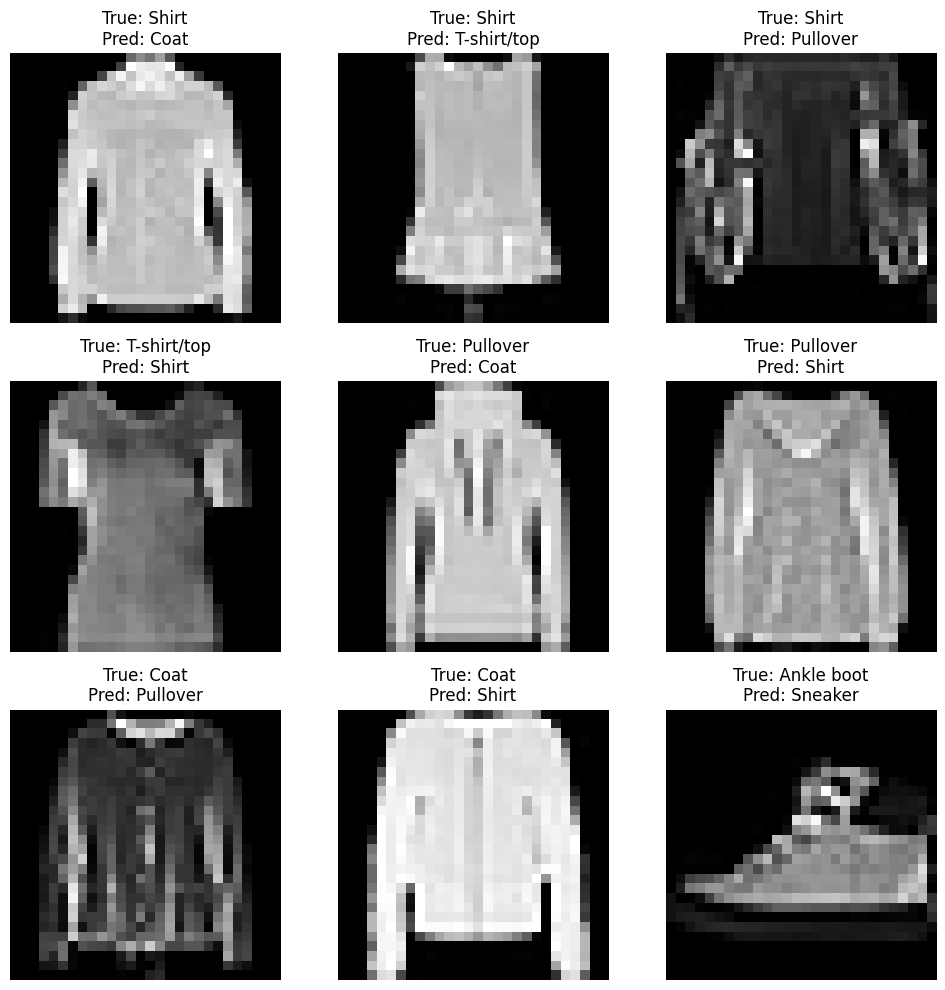

In [5]:
#CNN code (5/N)
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get the class names from the dataset (Fashion MNIST has 10 classes)
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Re-calculate confusion matrix to ensure we use the latest `cm` if needed
# (assuming y_test and y_pred_classes are still in scope from previous cell)
cm = confusion_matrix(y_test, y_pred_classes)

# Find multiple misclassified pairs based on the confusion matrix
# Collect all off-diagonal misclassification counts
misclassification_counts = []
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        if i != j and cm[i, j] > 0: # Only consider actual misclassifications
            misclassification_counts.append((cm[i, j], i, j)) # Store (count, true_label, predicted_label)

# Sort by count in descending order
misclassification_counts.sort(key=lambda x: x[0], reverse=True)

# Get up to 9 unique misclassified archetypes
unique_misclassified_archetypes = []
seen_pairs = set()
for count, true_class_idx, pred_class_idx in misclassification_counts:
    if (true_class_idx, pred_class_idx) not in seen_pairs:
        unique_misclassified_archetypes.append((true_class_idx, pred_class_idx))
        seen_pairs.add((true_class_idx, pred_class_idx))
    if len(unique_misclassified_archetypes) >= 9:
        break

print("Top misclassified archetypes:")
for true_idx, pred_idx in unique_misclassified_archetypes:
    count = cm[true_idx, pred_idx]
    print(f"  Actual '{class_names[true_idx]}' predicted as '{class_names[pred_idx]}' ({count} times)")

# Collect one example for each unique misclassified archetype
examples_to_display = []
for true_class_idx, pred_class_idx in unique_misclassified_archetypes:
    # Find an index where this specific misclassification occurred
    for idx in range(len(y_test)):
        if y_test[idx] == true_class_idx and y_pred_classes[idx] == pred_class_idx:
            examples_to_display.append(idx)
            break # Found one example for this archetype, move to the next

print(f"\nDisplaying {len(examples_to_display)} unique misclassified examples.")

# Display these specific misclassified examples
plt.figure(figsize=(10, 10))
for i, bad_index in enumerate(examples_to_display):
    plt.subplot(3, 3, i + 1)
    plt.imshow(x_test[bad_index].reshape(28, 28), cmap='gray')
    plt.title(f"True: {class_names[y_test[bad_index]]}\nPred: {class_names[y_pred_classes[bad_index]]}")
    plt.axis('off')
plt.tight_layout()
plt.show()

In [6]:
#CNN code (6/N)
from sklearn.metrics import classification_report

# Get class names (assuming they are already defined from previous cells)
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

# Generate and print the classification report
report = classification_report(y_test, y_pred_classes, target_names=class_names)
print(report)

              precision    recall  f1-score   support

 T-shirt/top       0.84      0.88      0.86      1000
     Trouser       0.98      0.98      0.98      1000
    Pullover       0.83      0.84      0.83      1000
       Dress       0.91      0.91      0.91      1000
        Coat       0.78      0.88      0.83      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.76      0.62      0.68      1000
     Sneaker       0.94      0.97      0.96      1000
         Bag       0.97      0.97      0.97      1000
  Ankle boot       0.97      0.96      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.90      0.90      0.90     10000
weighted avg       0.90      0.90      0.90     10000

